# Fine-tuning a model on a text classification task

## Loading the dataset

In [ ]:
from datasets import load_dataset

dataset = load_dataset("TCRG/airline_reviews")

# Split train into train + validation
split_dataset = dataset["train"].train_test_split(test_size=0.2, seed=42)

dataset = {
    "train": split_dataset["train"],
    "validation": split_dataset["test"],
    "test": dataset["test"]
}

print(dataset["train"])
print(dataset["validation"])
print(dataset["test"])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/186 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


airline_train.csv: 0.00B [00:00, ?B/s]

airline_test.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/6380 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/709 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label'],
    num_rows: 5104
})
Dataset({
    features: ['text', 'label'],
    num_rows: 1276
})
Dataset({
    features: ['text', 'label'],
    num_rows: 709
})


In [ ]:
import datasets
import random
import pandas as pd
from IPython.display import display, HTML

def show_random_elements(dataset, num_examples=10):
    assert num_examples <= len(dataset), "Can't pick more elements than there are in the dataset."
    picks = []
    for _ in range(num_examples):
        pick = random.randint(0, len(dataset)-1)
        while pick in picks:
            pick = random.randint(0, len(dataset)-1)
        picks.append(pick)

    df = pd.DataFrame(dataset[picks])
    for column, typ in dataset.features.items():
        if isinstance(typ, datasets.ClassLabel):
            df[column] = df[column].transform(lambda i: typ.names[i])
    display(HTML(df.to_html()))

In [ ]:
show_random_elements(dataset["train"])

,text,label
0,cool! Are there stairs at JFK? I can walk short distances but not stairs.,2
1,Shout-out to all the ground crews working in the cold! Thanks for what y'all do. (&amp; social media team for customer service),2
2,"drops a new video off the upcoming project #TheTakeover, produced by YpOnTheBeat https://t.co/IKQBdZA7TN RT",1
3,Will Flight 2155 that arrives at E11 be a penguin plane?,1
4,thank you,2
5,can I get some luv with a fallow?,1
6,"Bringing your ""A"" game with premium cabin dining. Nice! https://t.co/zgOQoxjBQY",2
7,we are trying to go as far away from King'sCollegeLondon as possible for charity today. Would you help us ? #jailbreak #RAG,1
8,"I would fly to Washington DC to see the actual Constitution and the Declaration of Independence, in honor of a US Navy friend.",1
9,"“ : Why not? We'd sure love to see you, Ruth! #JustDoIt #YouKnowYouWantTo ;)” you know me too well 💘",2


## Data Understanding
Inital EDA


All reviews count:
text     5813
label    5813
dtype: int64

NA counts:
text     0
label    0
dtype: int64
label
0    1915
1    1940
2    1958
Name: count, dtype: int64


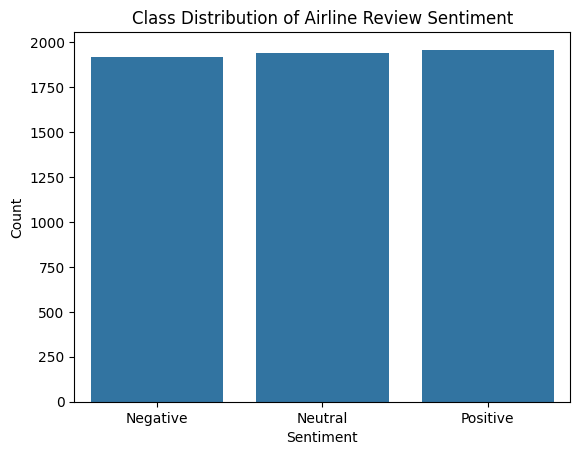


Word count summary:
Min: 1
Max: 31
Mean: 14.954240495441253


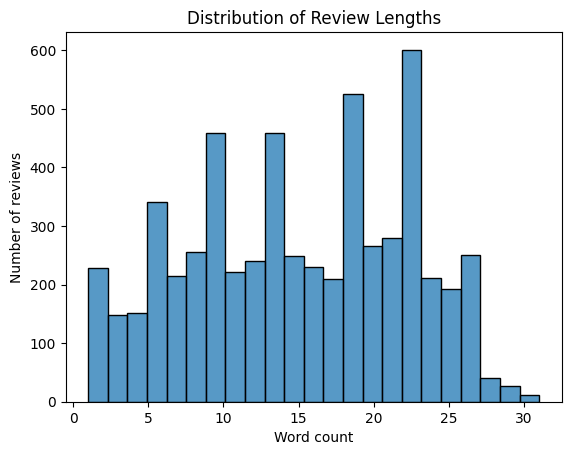

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

reviews_train = dataset["train"].to_pandas() # 6380
reviews_test = dataset["test"].to_pandas() # 709

# Combine train and test for EDA
reviews = pd.concat([reviews_train, reviews_test]) # 7089

print("\nAll reviews count:")
print(reviews.count())

# Check for NAs or empty strings
print("\nNA counts:")
print(reviews.isna().sum())

print(reviews["label"].value_counts().sort_index())

# Visualize
sns.countplot(x=reviews["label"], order=[0, 1, 2])
plt.xticks([0, 1, 2], ["Negative", "Neutral", "Positive"])
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.title("Class Distribution of Airline Review Sentiment")
plt.show()

reviews["word_count"] = reviews["text"].str.split().str.len()

print("\nWord count summary:")
print("Min:", reviews["word_count"].min())
print("Max:", reviews["word_count"].max())
print("Mean:", reviews["word_count"].mean())

sns.histplot(reviews["word_count"])
plt.xlabel("Word count")
plt.ylabel("Number of reviews")
plt.title("Distribution of Review Lengths")
plt.show()


In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
# word cloud for reviews classified as positive
# word cloud for reviews classified as neutral
# word cloud for reviews classified as negative

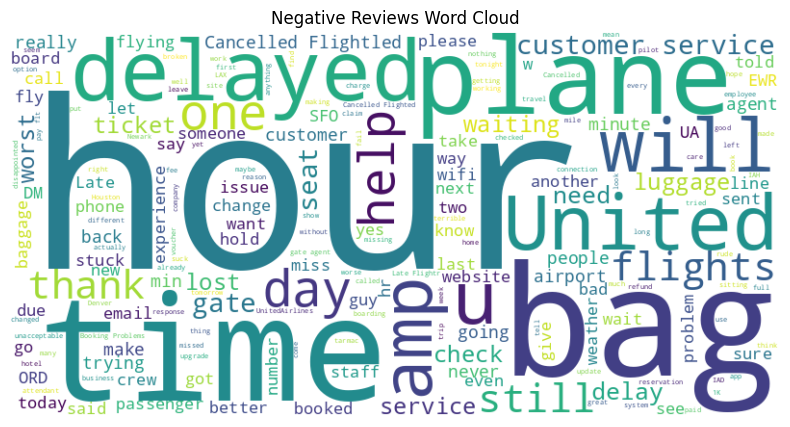

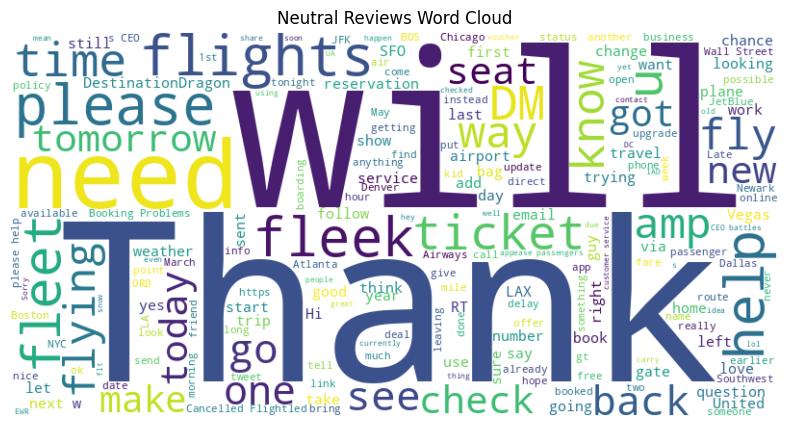

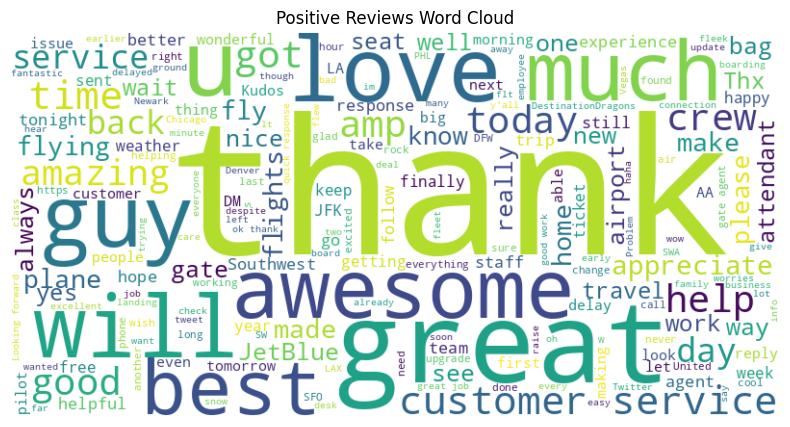

In [ ]:
from wordcloud import WordCloud, STOPWORDS

custom_stopwords = set(STOPWORDS)

custom_stopwords.update([
    "and", "to", "the", "of", "in", "for", "on", "with", "now",
    "flight", "airline", "airlines", "t", "co"
])

def plot_wordcloud(text, title):
    wc = WordCloud(
        width=800,
        height=400,
        background_color='white',
        stopwords=custom_stopwords
    ).generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(title)
    plt.axis('off')
    plt.show()

# Negative (0)
negative_text = " ".join(reviews[reviews["label"] == 0]["text"])
plot_wordcloud(negative_text, "Negative Reviews Word Cloud")

# Neutral (1)
neutral_text = " ".join(reviews[reviews["label"] == 1]["text"])
plot_wordcloud(neutral_text, "Neutral Reviews Word Cloud")

# Positive (2)
positive_text = " ".join(reviews[reviews["label"] == 2]["text"])
plot_wordcloud(positive_text, "Positive Reviews Word Cloud")

## Preprocessing the data

Preprocess text with transformers `Tokenizer`. Change commented out lines for DistilBERT, BERT, and RoBERTa models.

In [ ]:
from transformers import AutoTokenizer

# Uncomment desired model
model_checkpoint = "distilbert-base-uncased"
# model_checkpoint = "bert-base-uncased"
# model_checkpoint = "roberta-base"

tokenizer = AutoTokenizer.from_pretrained(model_checkpoint, use_fast=True)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
def preprocess_function(examples):
    return tokenizer(examples["text"], truncation=True)

encoded_dataset = {}
for split in dataset:
    encoded_dataset[split] = dataset[split].map(preprocess_function, batched=True)

Map:   0%|          | 0/5104 [00:00<?, ? examples/s]

## Fine-tuning the model

Load the pretrained model and fine-tune it, use the `AutoModelForSequenceClassification` class. Specify is the # of labels as 3: positive, negative, neutral.

In [ ]:
from transformers import AutoModelForSequenceClassification

num_labels = 3

model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=num_labels
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Setting up metrics


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "macro_f1": f1_score(labels, predictions, average="macro")
    }

In [ ]:
from transformers import TrainingArguments

batch_size = 16

training_args = TrainingArguments(

    # Uncomment desired model
    output_dir="./distilbert-airline-sentiment",
    #output_dir="./bert-airline-sentiment",
    #output_dir="./roberta-airline-sentiment",

    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    push_to_hub=False
)

In [ ]:
from transformers import Trainer, DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=encoded_dataset["train"],
    eval_dataset=encoded_dataset["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,No log,0.398660,0.851881,0.852247
2,0.550905,0.427496,0.844828,0.844958
3,0.550905,0.463253,0.847179,0.846558


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=957, training_loss=0.433762680898764, metrics={'train_runtime': 7340.5764, 'train_samples_per_second': 2.086, 'train_steps_per_second': 0.13, 'total_flos': 319271687824320.0, 'train_loss': 0.433762680898764, 'epoch': 3.0})

In [ ]:
trainer.evaluate()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': 0.3982716202735901,
 'eval_accuracy': 0.8518808777429467,
 'eval_macro_f1': 0.8522470696955539,
 'eval_runtime': 175.0982,
 'eval_samples_per_second': 7.287,
 'eval_steps_per_second': 0.457,
 'epoch': 3.0}

In [ ]:
test_results = trainer.predict(encoded_dataset["test"])
test_preds = np.argmax(test_results.predictions, axis=-1)

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(encoded_dataset["test"]["label"], test_preds))
print(confusion_matrix(encoded_dataset["test"]["label"], test_preds))

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


              precision    recall  f1-score   support

           0       0.86      0.83      0.85       236
           1       0.76      0.79      0.78       236
           2       0.84      0.84      0.84       237

    accuracy                           0.82       709
   macro avg       0.82      0.82      0.82       709
weighted avg       0.82      0.82      0.82       709

[[197  27  12]
 [ 24 187  25]
 [  7  31 199]]


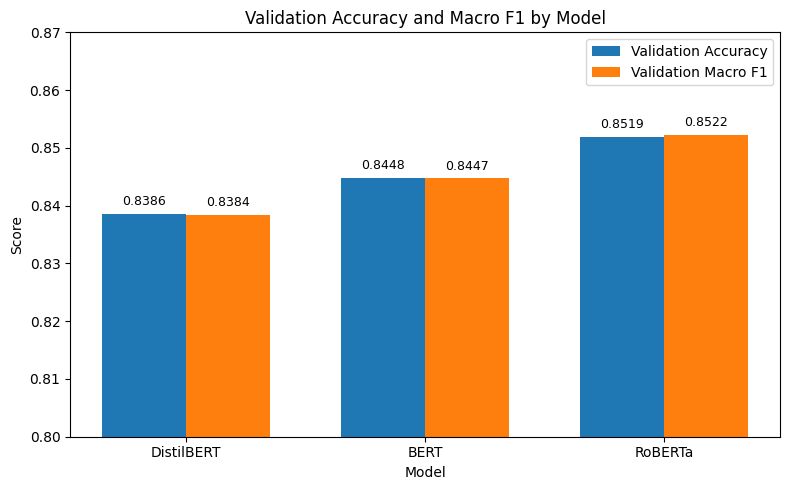

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data
models = ["DistilBERT", "BERT", "RoBERTa"]
val_accuracy = [0.8386, 0.8448, 0.8519]
val_macro_f1 = [0.8384, 0.8447, 0.8522]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8, 5))
bars1 = plt.bar(x - width/2, val_accuracy, width, label="Validation Accuracy")
bars2 = plt.bar(x + width/2, val_macro_f1, width, label="Validation Macro F1")

plt.xticks(x, models)
plt.ylim(0.80, 0.87)
plt.ylabel("Score")
plt.xlabel("Model")
plt.title("Validation Accuracy and Macro F1 by Model")
plt.legend()

# Add value labels above bars
for bar in bars1:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.001,
        f"{height:.4f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

for bar in bars2:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.001,
        f"{height:.4f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

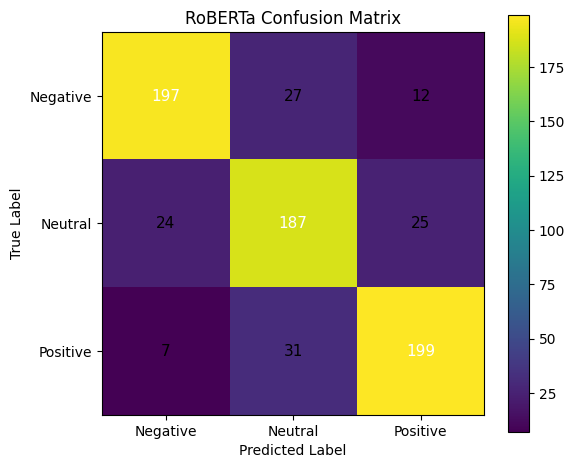

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# RoBERTa confusion matrix
cm = np.array([
    [197, 27, 12],
    [24, 187, 25],
    [7, 31, 199]
])

class_names = ["Negative", "Neutral", "Positive"]

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest")
plt.title("RoBERTa Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Add counts inside cells
threshold = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, str(cm[i, j]),
            ha="center",
            va="center",
            color="white" if cm[i, j] > threshold else "black",
            fontsize=11
        )

plt.tight_layout()
plt.savefig("roberta_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()